In [ ]:

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve,confusion_matrix, ConfusionMatrixDisplay

from sklearn.decomposition import PCA
from numpy.linalg import svd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
htru2 = '/content/drive/MyDrive/Project Semester 1/CMDS_ML_DATA/htru2/HTRU_2.csv'

In [ ]:
columns = [
    'mean_I',   # Mean of the integrated profile
    'std_IP',   # Standard deviation of the integrated profile
    'ek_IP',    # Excess kurtosis of the integrated profile
    'sk_IP',    # Skewness of the integrated profile
    'mean_DM',  # Mean of the DM-SNR curve
    'std_DM',   # Standard deviation of the DM-SNR curve
    'ek_DM',    # Excess kurtosis of the DM-SNR curve
    'sk_DM',    # Skewness of the DM-SNR curve
    'pulsar'    # Target: 0 = non-pulsar, 1 = pulsar
]

In [ ]:
htru2 = pd.read_csv(htru2, header=None, names=columns)

In [ ]:
htru2.columns

Index(['mean_I', 'std_IP', 'ek_IP', 'sk_IP', 'mean_DM', 'std_DM', 'ek_DM',
       'sk_DM', 'pulsar'],
      dtype='object')

In [ ]:
htru2.head()

,mean_I,std_IP,ek_IP,sk_IP,mean_DM,std_DM,ek_DM,sk_DM,pulsar
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [ ]:
htru2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mean_I   17898 non-null  float64
 1   std_IP   17898 non-null  float64
 2   ek_IP    17898 non-null  float64
 3   sk_IP    17898 non-null  float64
 4   mean_DM  17898 non-null  float64
 5   std_DM   17898 non-null  float64
 6   ek_DM    17898 non-null  float64
 7   sk_DM    17898 non-null  float64
 8   pulsar   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [ ]:
print(htru2.shape)

(17898, 9)


In [ ]:
print(htru2.describe())

             mean_I        std_IP         ek_IP         sk_IP       mean_DM  \
count  17898.000000  17898.000000  17898.000000  17898.000000  17898.000000   
mean     111.079968     46.549532      0.477857      1.770279     12.614400   
std       25.652935      6.843189      1.064040      6.167913     29.472897   
min        5.812500     24.772042     -1.876011     -1.791886      0.213211   
25%      100.929688     42.376018      0.027098     -0.188572      1.923077   
50%      115.078125     46.947479      0.223240      0.198710      2.801839   
75%      127.085938     51.023202      0.473325      0.927783      5.464256   
max      192.617188     98.778911      8.069522     68.101622    223.392141   

             std_DM         ek_DM         sk_DM        pulsar  
count  17898.000000  17898.000000  17898.000000  17898.000000  
mean      26.326515      8.303556    104.857709      0.091574  
std       19.470572      4.506092    106.514540      0.288432  
min        7.370432     -3.13927

In [ ]:
print(htru2['pulsar'].value_counts())

pulsar
0    16259
1     1639
Name: count, dtype: int64


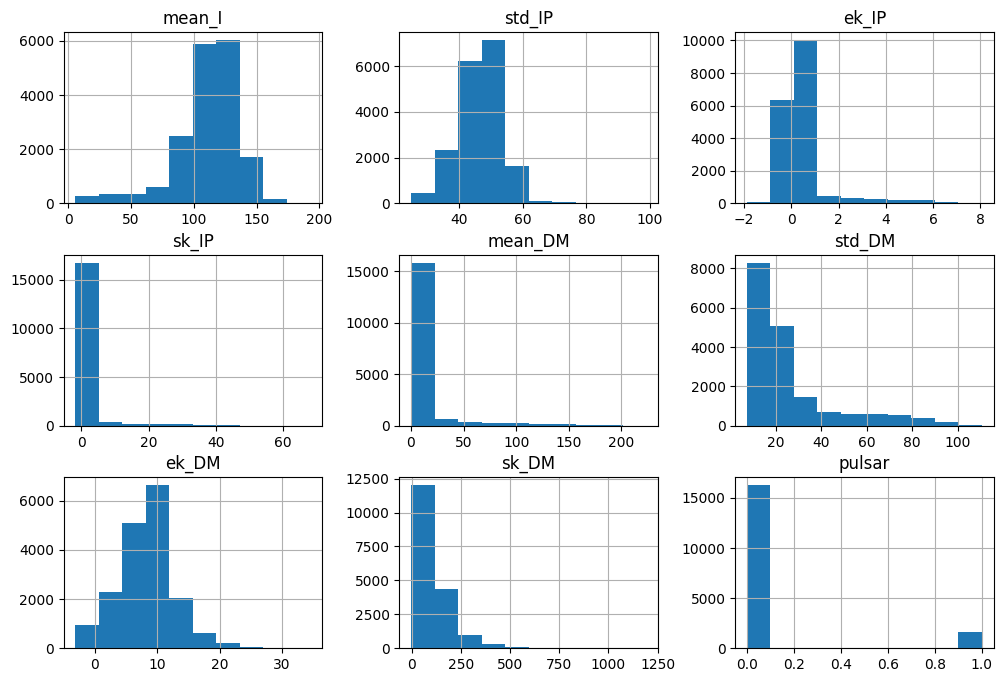

In [ ]:
htru2.hist(figsize=(12,8))
plt.show()

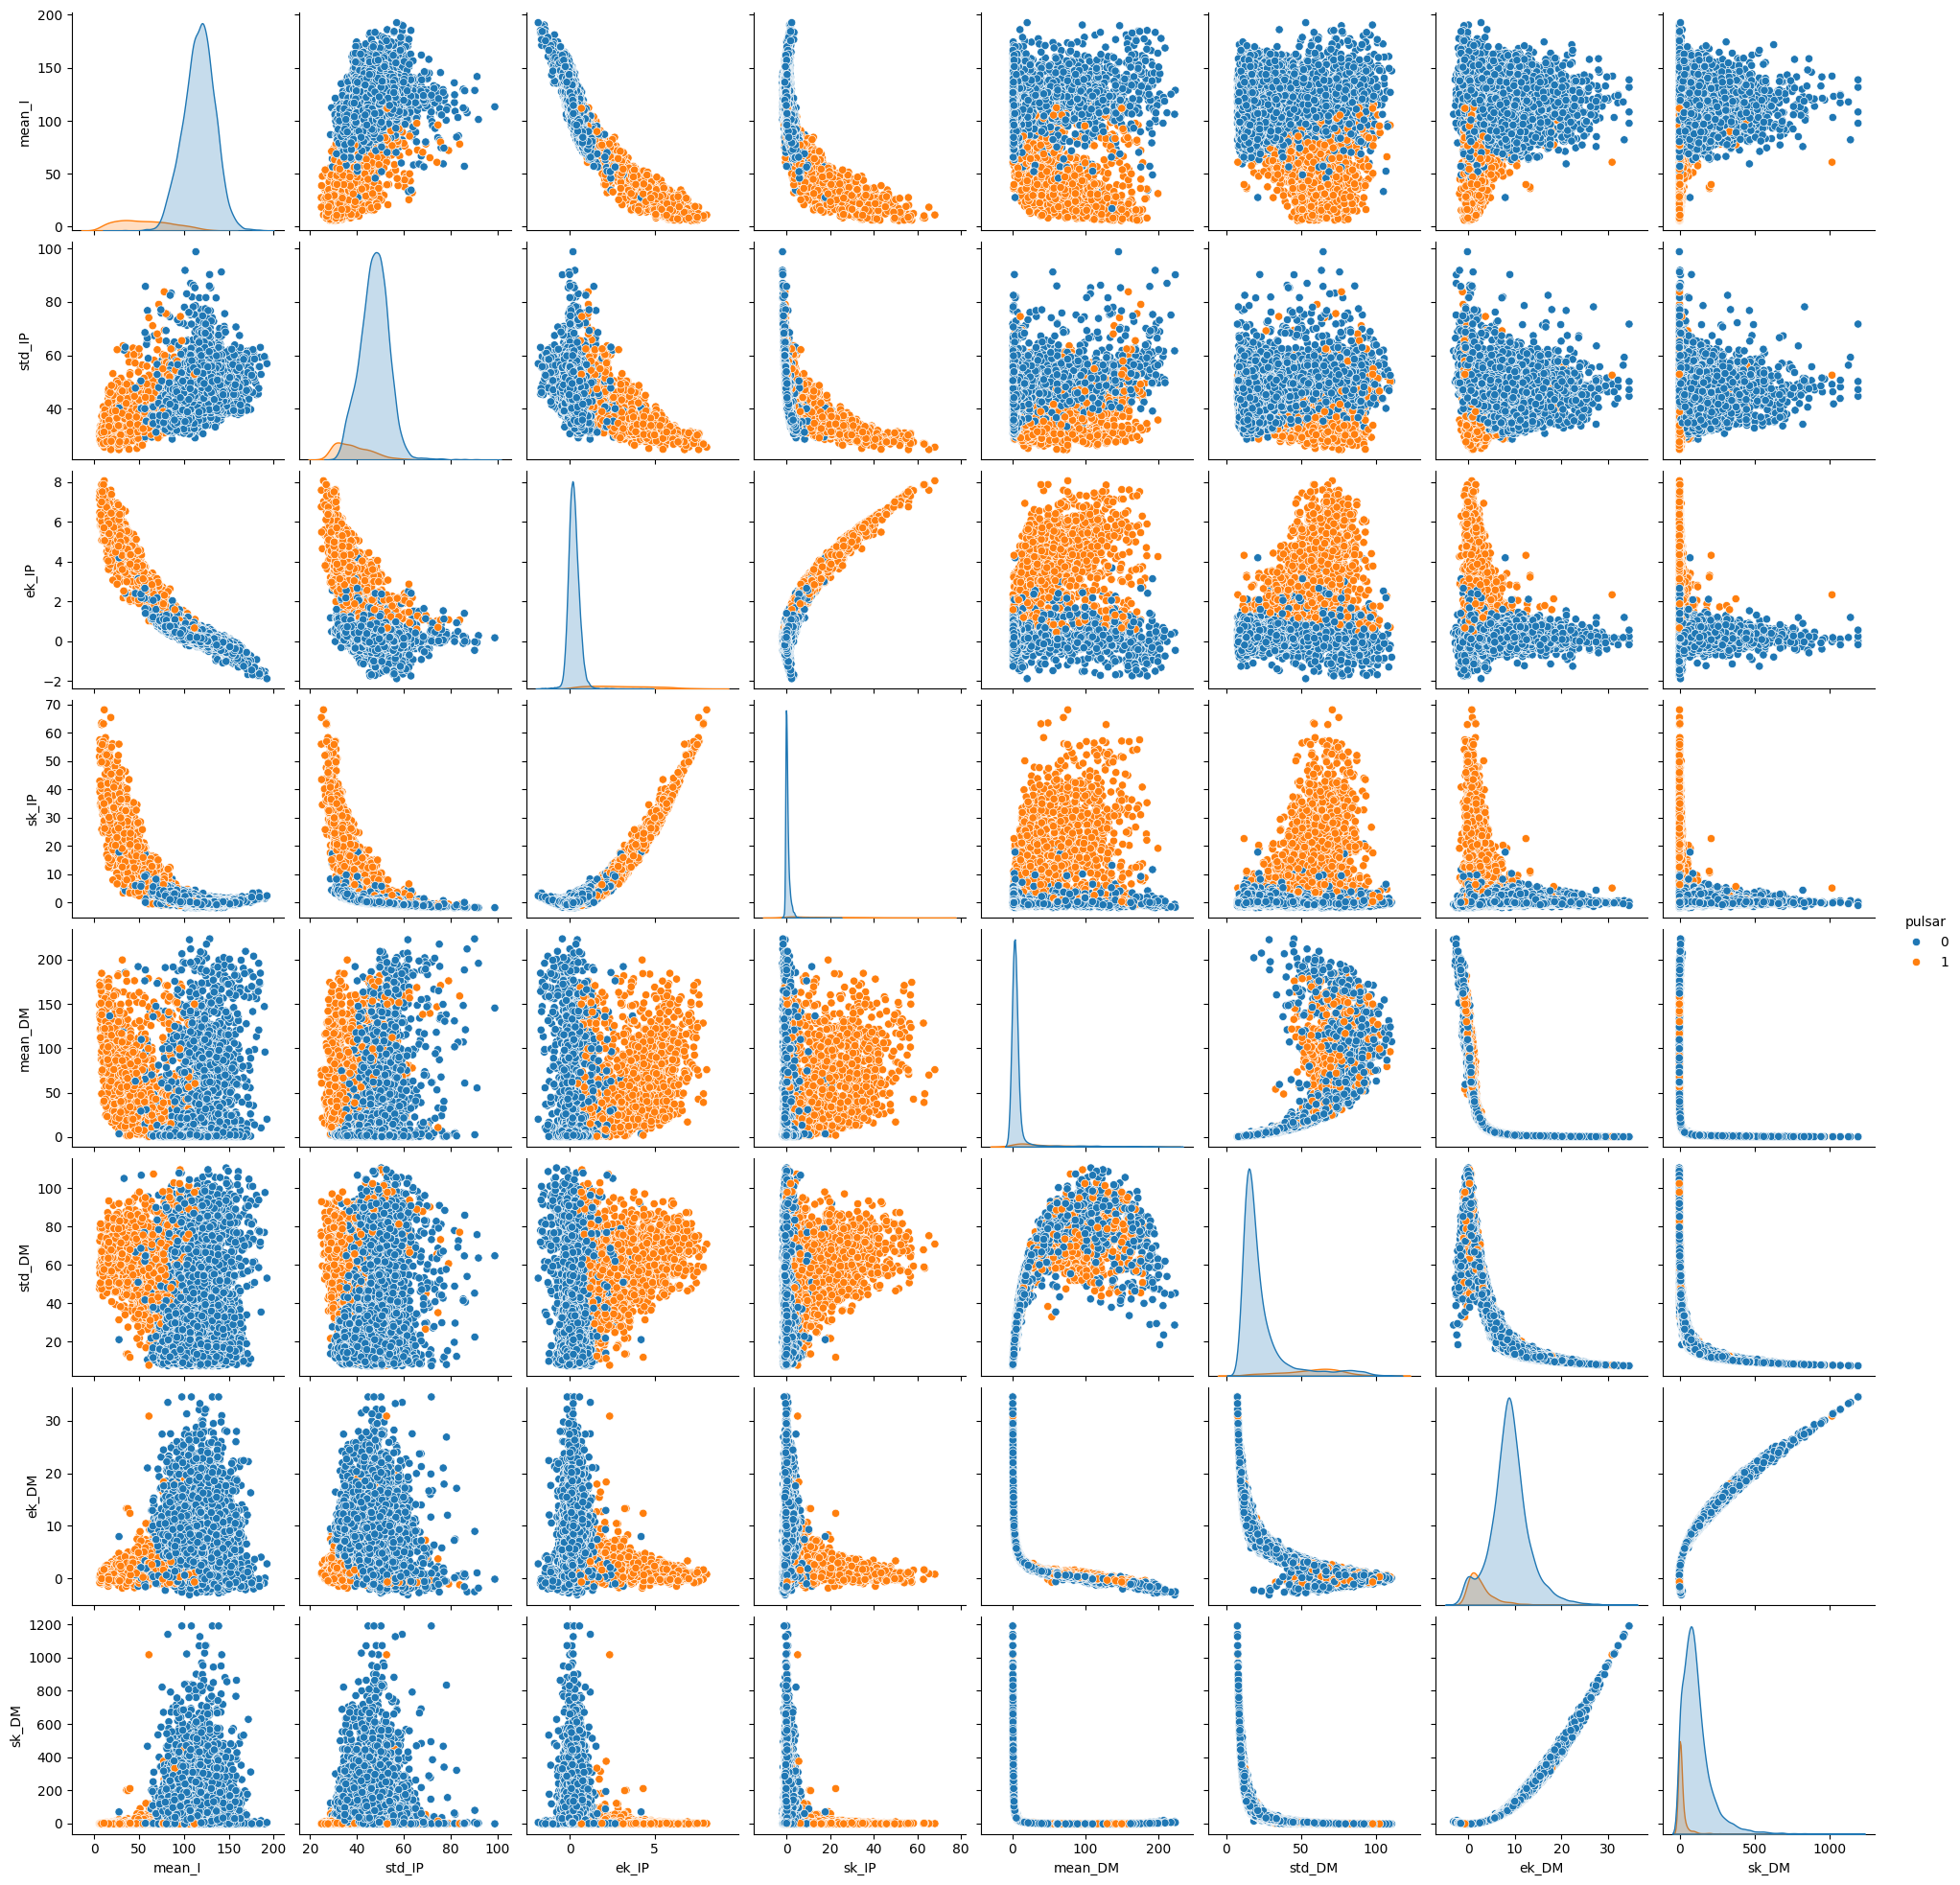

In [ ]:
sns.pairplot(htru2, hue='pulsar')

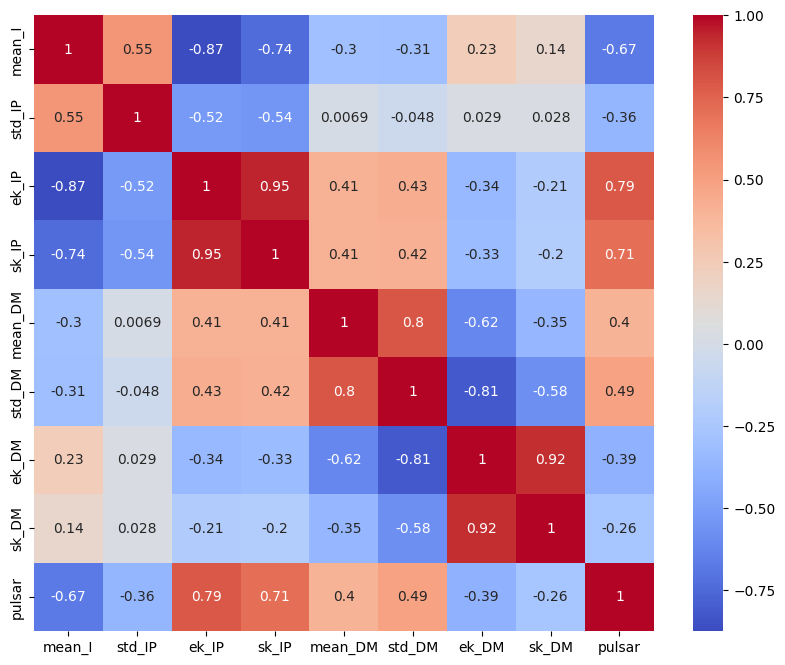

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(htru2.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
htru2.isnull().sum()

,0
mean_I,0
std_IP,0
ek_IP,0
sk_IP,0
mean_DM,0
std_DM,0
ek_DM,0
sk_DM,0
pulsar,0


In [ ]:
# outlier
Q1 = htru2.quantile(0.25)
Q3 = htru2.quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#print(lower_bound)
#print(upper_bound)


mean_I      26.156250
std_IP       8.647184
ek_IP        0.446227
sk_IP        1.116355
mean_DM      3.541179
std_DM      13.990773
ek_DM        4.921454
sk_DM      104.348826
pulsar       0.000000
dtype: float64


<Axes: xlabel='pulsar', ylabel='count'>

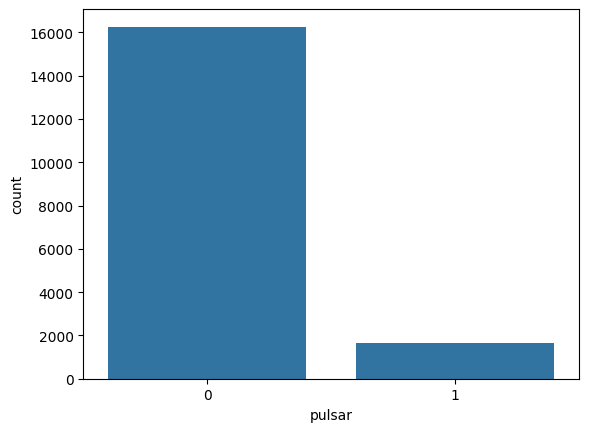

In [ ]:
sns.countplot(x='pulsar', data=htru2)

In [ ]:
features = htru2.drop('pulsar', axis=1)
target = htru2['pulsar']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced"
    ),
    "SVM (Linear)": SVC(
        kernel="linear", class_weight="balanced", probability=True
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    )
}

In [ ]:
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "LinearSVM": SVC(kernel='linear', class_weight="balanced", probability=True),
    "RBF_SVM": SVC(kernel='rbf', class_weight="balanced", probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}
results_classifiers = {}

In [ ]:
for name, clf in classifiers.items():

    if name in ["LogisticRegression", "LinearSVM", "RBF_SVM", "kNN"]:
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]

    results_classifiers[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [ ]:
results_df = pd.DataFrame(results_classifiers).T
results_df

,Accuracy,F1-score,ROC-AUC
LogisticRegression,0.969553,0.847125,0.972736
LinearSVM,0.974860,0.869942,0.970770
RBF_SVM,0.971788,0.855920,0.966131
RandomForest,0.980168,0.888189,0.970490
GradientBoosting,0.981285,0.895149,0.977009
kNN,0.980447,0.888179,0.951616


In [ ]:
X_syn = htru2.drop('pulsar', axis=1)
y_syn = htru2['pulsar']

X_pulsar = X_syn[y_syn == 1]


In [ ]:
# Mean vector
mu = X_pulsar.mean().values   # shape: (8,)

# Covariance matrix
cov = np.cov(X_pulsar.T)      # shape: (8, 8)


In [ ]:
n_synthetic = 5000

X_synthetic = np.random.multivariate_normal(
    mean=mu,
    cov=cov,
    size=n_synthetic
)

synthetic_df = pd.DataFrame(
    X_synthetic,
    columns=X_syn.columns
)

synthetic_df['pulsar'] = 1


In [ ]:
df_balanced = pd.concat([htru2, synthetic_df], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['pulsar'].value_counts())


pulsar
0    16259
1     6639
Name: count, dtype: int64


In [ ]:
X_bal = df_balanced.drop('pulsar', axis=1)
y_bal = df_balanced['pulsar']

In [ ]:
X_synth = synthetic_df.drop('pulsar', axis=1)

print(X_syn.mean())
print(X_synth.mean())

print(X_syn.std())
print(X_synth.std())

mean_I     111.079968
std_IP      46.549532
ek_IP        0.477857
sk_IP        1.770279
mean_DM     12.614400
std_DM      26.326515
ek_DM        8.303556
sk_DM      104.857709
dtype: float64
mean_I     57.035414
std_IP     38.698296
ek_IP       3.110573
sk_IP      15.414436
mean_DM    48.965961
std_DM     55.842263
ek_DM       2.830147
sk_DM      18.803629
dtype: float64
mean_I      25.652935
std_IP       6.843189
ek_IP        1.064040
sk_IP        6.167913
mean_DM     29.472897
std_DM      19.470572
ek_DM        4.506092
sk_DM      106.514540
dtype: float64
mean_I     30.175036
std_IP      8.029816
ek_IP       1.881692
sk_IP      14.016239
mean_DM    45.768541
std_DM     19.956956
ek_DM       3.141101
sk_DM      50.963682
dtype: float64


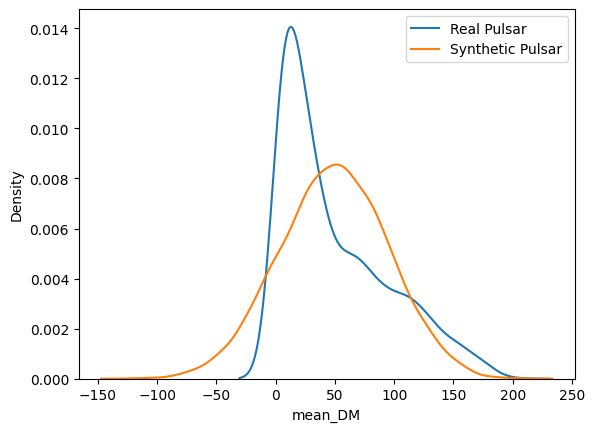

In [ ]:
sns.kdeplot(X_pulsar['mean_DM'], label='Real Pulsar')
sns.kdeplot(X_synth['mean_DM'], label='Synthetic Pulsar')
plt.legend()
plt.show()


In [ ]:
X_bal_train, X_bal_test, y_bal_train, y_bal_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

In [ ]:
scaler = StandardScaler()
x_bal_train_scaled = scaler.fit_transform(X_bal_train)
x_bal_test_scaled = scaler.transform(X_bal_test)

In [ ]:
results_augmented = {}

for name, model in classifiers.items():
    model.fit(x_bal_train_scaled, y_bal_train)

    y_pred = model.predict(x_bal_test_scaled)
    y_prob = model.predict_proba(x_bal_test_scaled)[:, 1]

    results_augmented[name] = {
        "Accuracy": accuracy_score(y_bal_test, y_pred),
        "F1-score": f1_score(y_bal_test, y_pred),
        "ROC-AUC": roc_auc_score(y_bal_test, y_prob)
    }

In [ ]:
results_df_aug = pd.DataFrame(results_augmented).T
results_df_aug


,Accuracy,F1-score,ROC-AUC
LogisticRegression,0.965721,0.941221,0.986556
LinearSVM,0.965502,0.940467,0.986358
RBF_SVM,0.981878,0.968596,0.993597
RandomForest,0.982969,0.970365,0.994619
GradientBoosting,0.982751,0.969996,0.995519
kNN,0.976856,0.959136,0.984192


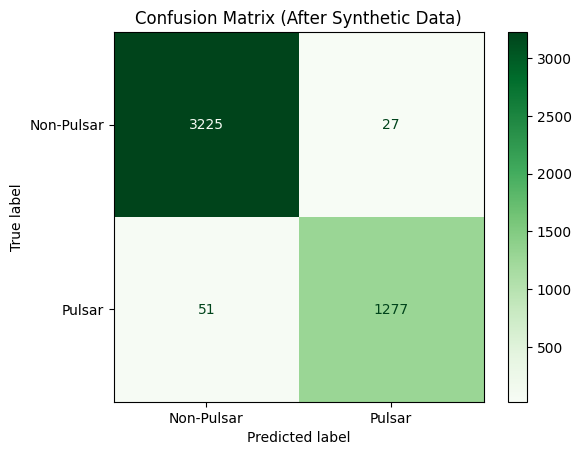

Confusion Matrix AFTER augmentation:
[[3225   27]
 [  51 1277]]


In [ ]:


gb_aug = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_aug.fit(X_bal_train, y_bal_train)

y_pred_aug = gb_aug.predict(X_bal_test)

cm_aug = confusion_matrix(y_bal_test, y_pred_aug)

disp_aug = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=["Non-Pulsar", "Pulsar"]
)

disp_aug.plot(cmap='Greens')
plt.title("Confusion Matrix (After Synthetic Data)")
plt.show()

print("Confusion Matrix AFTER augmentation:")
print(cm_aug)


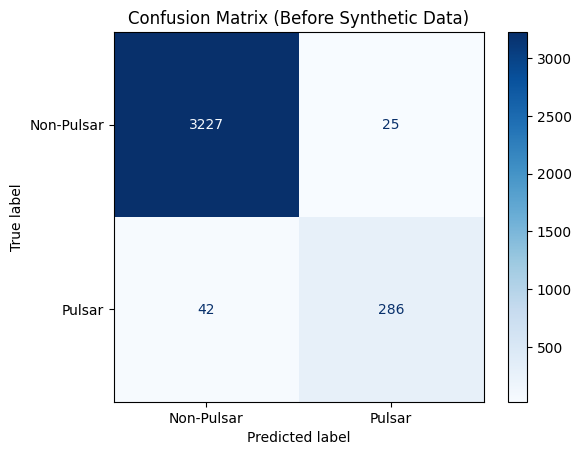

Confusion Matrix BEFORE augmentation:
[[3227   25]
 [  42  286]]


In [ ]:
gb_baseline = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_baseline.fit(X_train, y_train)

y_pred_base = gb_baseline.predict(X_test)

cm_base = confusion_matrix(y_test, y_pred_base)

disp_base = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=["Non-Pulsar", "Pulsar"]
)

disp_base.plot(cmap='Blues')
plt.title("Confusion Matrix (Before Synthetic Data)")
plt.show()

print("Confusion Matrix BEFORE augmentation:")
print(cm_base)


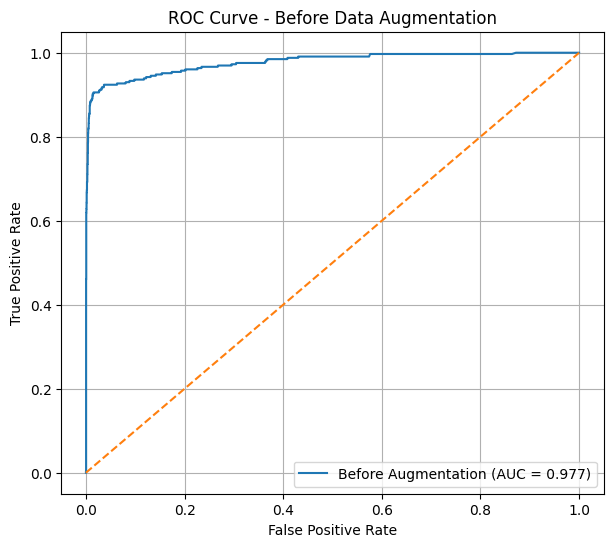

In [ ]:


y_prob_base = gb_baseline.predict_proba(X_test)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
roc_auc_base = roc_auc_score(y_test, y_prob_base)

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f'Before Augmentation (AUC = {roc_auc_base:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Before Data Augmentation')
plt.legend(loc='lower right')
plt.grid()
plt.show()


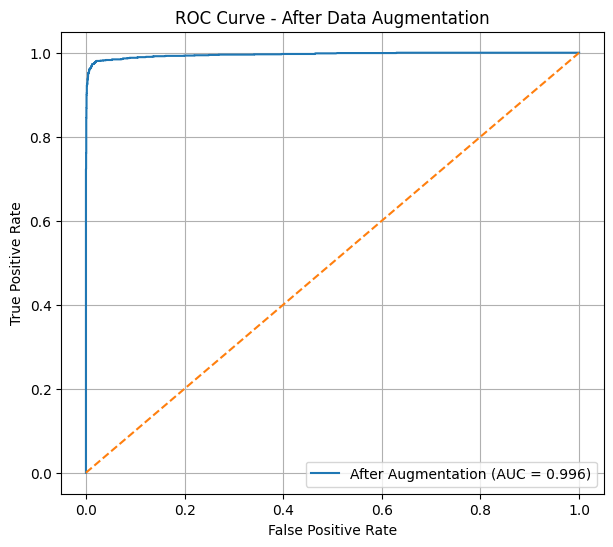

In [ ]:


y_prob_aug = gb_aug.predict_proba(X_bal_test)[:, 1]

fpr_aug, tpr_aug, _ = roc_curve(y_bal_test, y_prob_aug)
roc_auc_aug = roc_auc_score(y_bal_test, y_prob_aug)

plt.figure(figsize=(7, 6))
plt.plot(fpr_aug, tpr_aug, label=f'After Augmentation (AUC = {roc_auc_aug:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - After Data Augmentation')
plt.legend(loc='lower right')
plt.grid()
plt.show()


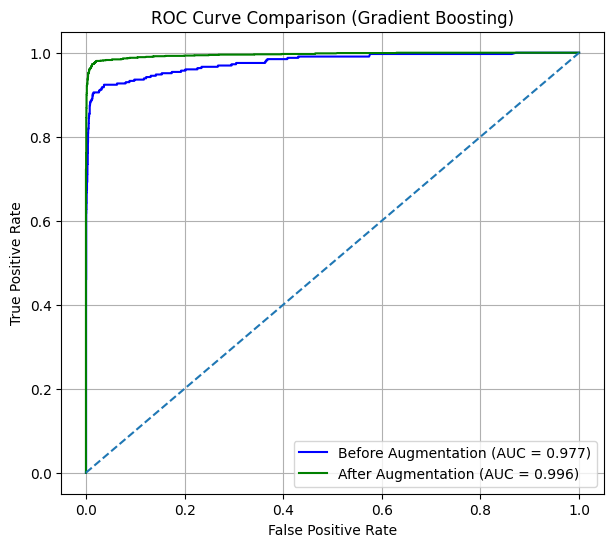

In [ ]:


plt.figure(figsize=(7, 6))

plt.plot(
    fpr_base, tpr_base,
    label=f'Before Augmentation (AUC = {roc_auc_base:.3f})',
    color='blue'
)

plt.plot(
    fpr_aug, tpr_aug,
    label=f'After Augmentation (AUC = {roc_auc_aug:.3f})',
    color='green'
)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Gradient Boosting)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
